In [1]:
# Faster approach using spatial index on individual segments
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize
from pathlib import Path
from shapely.geometry import box
import warnings
warnings.filterwarnings('ignore')
from tqdm.notebook import tqdm

# Load inputs
selected = pd.read_csv(r"C:\Users\lstojano\Desktop\teza\road_extraction_slovenia\data\processed\metadata\selected_orthophotos.csv")

# Load INDIVIDUAL buffered segments (not dissolved)
roads_raw = gpd.read_file(r"C:\Users\lstojano\Desktop\teza\road_extraction_slovenia\data\raw\roads\roads_102109.gpkg")
study = gpd.read_file(r"C:\Users\lstojano\Desktop\teza\road_extraction_slovenia\data\processed\study_areas.gpkg")

# Rebuild individual buffered segments quickly
class_map = {
    'AC': 1, 'HC': 1, 'G1': 1, 'G2': 1, 'R1': 1,
    'GZ': 2, 'R2': 2, 'R3': 2, 'RT': 2, 'LC': 2, 'LZ': 2,
    'LG': 3, 'LK': 3, 'JP': 3, 'KD': 3, 'KJ': 3, 'NK': 3, 'PP': 3
}
buffer_min = {1: 3.0, 2: 2.0, 3: 1.5}
buffer_fallback = {1: 4.0, 2: 2.0, 3: 1.0}

print("Clipping roads to study area...")
study_boundary = study.dissolve()
roads_clipped = gpd.clip(roads_raw, study_boundary)
roads_clipped = roads_clipped[roads_clipped['KAT_CES'].notna()].copy()
roads_clipped['road_class'] = roads_clipped['KAT_CES'].map(class_map)
roads_clipped = roads_clipped[roads_clipped['road_class'].notna()].copy()

# Fix SIRCES=0
for cls in [1, 2, 3]:
    mask = (roads_clipped['road_class'] == cls) & (roads_clipped['SIRCES'] == 0)
    roads_clipped.loc[mask, 'SIRCES'] = buffer_fallback[cls] * 2

# Calculate buffer
roads_clipped['buffer_m'] = roads_clipped.apply(
    lambda row: max(row['SIRCES'] / 2, buffer_min[int(row['road_class'])]),
    axis=1
)

# Apply buffers
print("Buffering segments...")
from shapely.geometry import CAP_STYLE, JOIN_STYLE
roads_clipped['geometry'] = roads_clipped.apply(
    lambda row: row['geometry'].buffer(
        row['buffer_m'],
        cap_style=CAP_STYLE.flat,
        join_style=JOIN_STYLE.mitre
    ), axis=1
)

# Keep only needed columns
roads_buffered = roads_clipped[['road_class', 'geometry']].copy()
roads_buffered['road_class'] = roads_buffered['road_class'].astype(int)
roads_buffered = roads_buffered.reset_index(drop=True)

# Build spatial index
print("Building spatial index...")
sindex = roads_buffered.sindex

print(f"Ready. Total buffered segments: {len(roads_buffered)}")

Clipping roads to study area...
Buffering segments...
Building spatial index...
Ready. Total buffered segments: 122533


In [4]:
# Test spatial index only
import time

print("Testing spatial index...")
t = time.time()
test_bounds = (455000, 95000, 457250, 98000)
result = list(sindex.intersection(test_bounds))
print(f"Done in {time.time()-t:.2f}s")
print(f"Found: {len(result)} candidates")

Testing spatial index...
Done in 0.00s
Found: 15 candidates


In [5]:
# Check first tile data
row = selected.iloc[0]
print(f"Tile: {row['tile_name']}")
print(f"Bounds: {row['x_min']}, {row['y_min']}, {row['x_max']}, {row['y_max']}")

tile_box = box(row['x_min'], row['y_min'], row['x_max'], row['y_max'])
candidates_idx = list(sindex.intersection(tile_box.bounds))
print(f"Candidates found: {len(candidates_idx)}")

# Check the candidates
candidates = roads_buffered.iloc[candidates_idx].copy()
print(f"\nRoad classes in tile:")
print(candidates['road_class'].value_counts())
print(f"\nGeometry types:")
print(candidates.geometry.geom_type.value_counts())
print(f"\nAny invalid geometries: {(~candidates.geometry.is_valid).sum()}")

Tile: A070658C
Bounds: 376250.125, 126999.875, 378500.125, 129999.875
Candidates found: 2

Road classes in tile:
road_class
3    1
2    1
Name: count, dtype: int64

Geometry types:
MultiPolygon    1
Polygon         1
Name: count, dtype: int64

Any invalid geometries: 0


In [6]:
import time

row = selected.iloc[0]
tile_box = box(row['x_min'], row['y_min'], row['x_max'], row['y_max'])
candidates_idx = list(sindex.intersection(tile_box.bounds))
candidates = roads_buffered.iloc[candidates_idx].copy()

print("Testing intersects filter...")
t = time.time()
mask = candidates.geometry.intersects(tile_box)
print(f"Done: {time.time()-t:.2f}s — {mask.sum()} pass")

print("\nTesting intersection clip...")
for i, geom in enumerate(candidates.geometry):
    t = time.time()
    result = geom.intersection(tile_box)
    print(f"Geometry {i}: {time.time()-t:.2f}s — type: {geom.geom_type} — vertices: {len(geom.exterior.coords) if geom.geom_type == 'Polygon' else 'multi'}")

Testing intersects filter...
Done: 0.01s — 2 pass

Testing intersection clip...
Geometry 0: 0.00s — type: MultiPolygon — vertices: multi
Geometry 1: 0.00s — type: Polygon — vertices: 628


In [7]:
# Test loop on 5 tiles without tqdm
MASK_DIR = Path(r"C:\Users\lstojano\Desktop\teza\road_extraction_slovenia\data\processed\road_labels\masks")
TILE_W_PX = 9000
TILE_H_PX = 12000

print("Testing 5 tiles...")

for idx, row in selected.head(5).iterrows():
    print(f"Processing tile {idx}: {row['tile_name']}...", end=' ')
    
    mask_path = MASK_DIR / f"{row['tile_name']}_mask.tif"
    tile_box = box(row['x_min'], row['y_min'], row['x_max'], row['y_max'])
    candidates_idx = list(sindex.intersection(tile_box.bounds))
    
    if len(candidates_idx) == 0:
        mask = np.zeros((TILE_H_PX, TILE_W_PX), dtype=np.uint8)
    else:
        candidates = roads_buffered.iloc[candidates_idx].copy()
        candidates = candidates[candidates.geometry.intersects(tile_box)].copy()
        candidates['geometry'] = candidates.geometry.intersection(tile_box)
        candidates = candidates[~candidates.geometry.is_empty].copy()
        mask = np.zeros((TILE_H_PX, TILE_W_PX), dtype=np.uint8)
        transform = from_bounds(
            row['x_min'], row['y_min'],
            row['x_max'], row['y_max'],
            TILE_W_PX, TILE_H_PX
        )
        for cls in [3, 2, 1]:
            cls_geoms = candidates[candidates['road_class'] == cls]
            if len(cls_geoms) == 0:
                continue
            shapes = [(geom, cls) for geom in cls_geoms.geometry]
            burned = rasterize(
                shapes=shapes,
                out_shape=(TILE_H_PX, TILE_W_PX),
                transform=transform,
                fill=0,
                dtype=np.uint8
            )
            mask = np.where(burned > 0, burned, mask)
    
    transform = from_bounds(
        row['x_min'], row['y_min'],
        row['x_max'], row['y_max'],
        TILE_W_PX, TILE_H_PX
    )
    with rasterio.open(
        mask_path, 'w',
        driver='GTiff',
        height=TILE_H_PX,
        width=TILE_W_PX,
        count=1,
        dtype=np.uint8,
        crs='ESRI:102109',
        transform=transform,
        compress='lzw'
    ) as dst:
        dst.write(mask, 1)
    
    print(f"done")

print("\nAll 5 tiles complete.")

Testing 5 tiles...
Processing tile 0: A070658C... done
Processing tile 1: A070758C... done
Processing tile 2: A070858C... done
Processing tile 3: A070958C... done
Processing tile 4: A071058C... done

All 5 tiles complete.


In [8]:
# Full rasterization - no tqdm
errors = []
skipped = 0
processed = 0
total = len(selected)

print(f"Starting rasterization of {total} tiles...")
print("Progress will print every 50 tiles\n")

for idx, row in selected.iterrows():
    
    mask_path = MASK_DIR / f"{row['tile_name']}_mask.tif"
    
    if mask_path.exists():
        skipped += 1
        continue
    
    try:
        tile_box = box(row['x_min'], row['y_min'], row['x_max'], row['y_max'])
        candidates_idx = list(sindex.intersection(tile_box.bounds))
        
        if len(candidates_idx) == 0:
            mask = np.zeros((TILE_H_PX, TILE_W_PX), dtype=np.uint8)
        else:
            candidates = roads_buffered.iloc[candidates_idx].copy()
            candidates = candidates[candidates.geometry.intersects(tile_box)].copy()
            candidates['geometry'] = candidates.geometry.intersection(tile_box)
            candidates = candidates[~candidates.geometry.is_empty].copy()
            mask = np.zeros((TILE_H_PX, TILE_W_PX), dtype=np.uint8)
            transform = from_bounds(
                row['x_min'], row['y_min'],
                row['x_max'], row['y_max'],
                TILE_W_PX, TILE_H_PX
            )
            for cls in [3, 2, 1]:
                cls_geoms = candidates[candidates['road_class'] == cls]
                if len(cls_geoms) == 0:
                    continue
                shapes = [(geom, cls) for geom in cls_geoms.geometry]
                burned = rasterize(
                    shapes=shapes,
                    out_shape=(TILE_H_PX, TILE_W_PX),
                    transform=transform,
                    fill=0,
                    dtype=np.uint8
                )
                mask = np.where(burned > 0, burned, mask)
        
        transform = from_bounds(
            row['x_min'], row['y_min'],
            row['x_max'], row['y_max'],
            TILE_W_PX, TILE_H_PX
        )
        with rasterio.open(
            mask_path, 'w',
            driver='GTiff',
            height=TILE_H_PX,
            width=TILE_W_PX,
            count=1,
            dtype=np.uint8,
            crs='ESRI:102109',
            transform=transform,
            compress='lzw'
        ) as dst:
            dst.write(mask, 1)
        
        processed += 1
        
        if processed % 50 == 0:
            print(f"  {processed}/{total} processed ({100*processed/total:.1f}%)")
    
    except Exception as e:
        errors.append({'tile': row['tile_name'], 'error': str(e)})

print(f"\n=== Rasterization complete ===")
print(f"Processed:  {processed}")
print(f"Skipped:    {skipped}")
print(f"Errors:     {len(errors)}")
if errors:
    for e in errors[:5]:
        print(f"  {e['tile']}: {e['error']}")

Starting rasterization of 1088 tiles...
Progress will print every 50 tiles


=== Rasterization complete ===
Processed:  0
Skipped:    1088
Errors:     0


In [9]:
# Check how many masks actually exist
mask_files = list(MASK_DIR.glob("*.tif"))
print(f"Mask files on disk: {len(mask_files)}")
print("\nFirst few:")
for f in mask_files[:5]:
    print(f"  {f.name}")

Mask files on disk: 1025

First few:
  A070658C_mask.tif
  A070758C_mask.tif
  A070858C_mask.tif
  A070958C_mask.tif
  A071058C_mask.tif


In [10]:
# Find missing tiles
existing = set(f.stem.replace('_mask', '') for f in MASK_DIR.glob("*.tif"))
all_tiles = set(selected['tile_name'].tolist())
missing = all_tiles - existing

print(f"Total expected:  {len(all_tiles)}")
print(f"Already done:    {len(existing)}")
print(f"Missing:         {len(missing)}")
print(f"\nMissing tiles:")
for t in sorted(missing):
    print(f"  {t}")

Total expected:  1025
Already done:    1025
Missing:         0

Missing tiles:


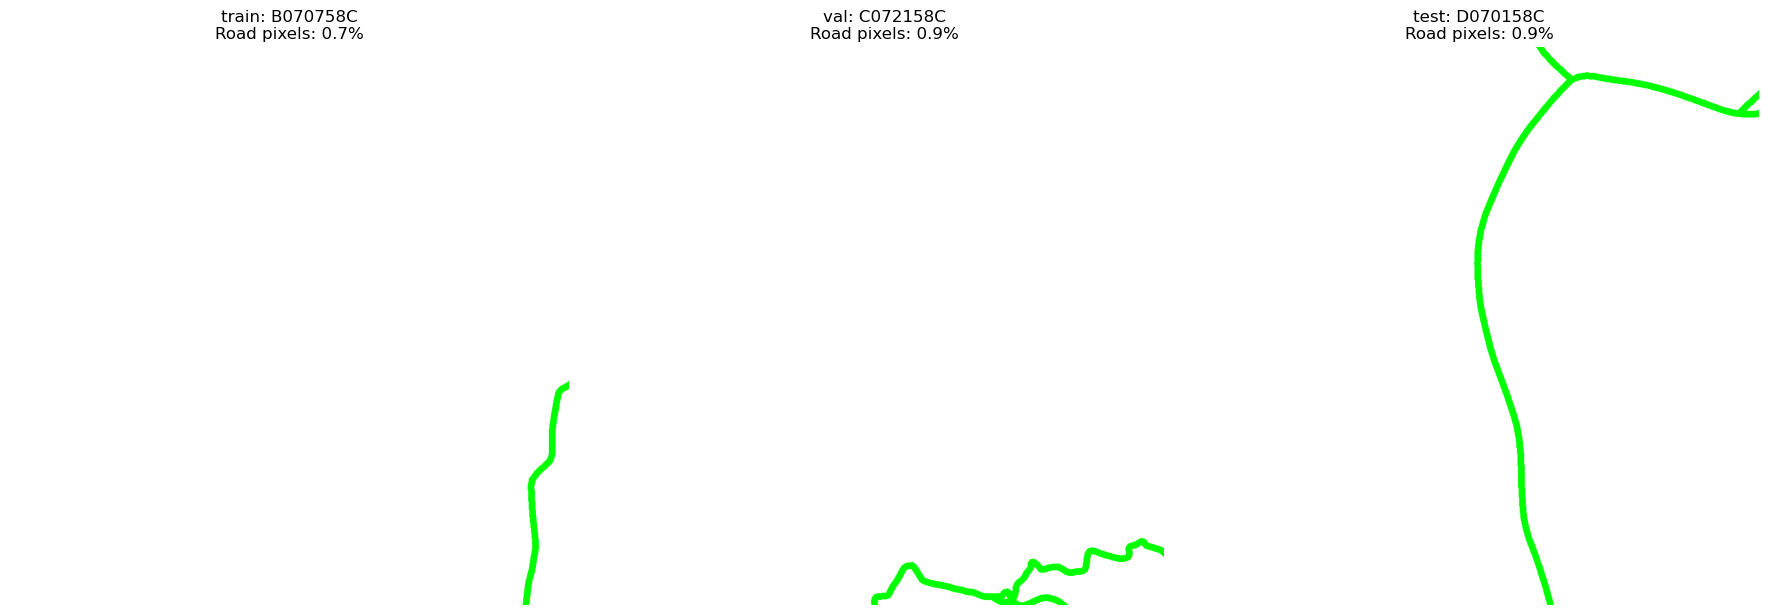

In [12]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

# Pick one tile from each split to verify
test_tiles = {
    'train': 'B070758C',
    'val':   'C072158C',
    'test':  'D070158C'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {
    0: [255, 255, 255],  # background - white
    1: [255, 0,   0],    # major roads - red
    2: [0,   0,   255],  # local roads - blue
    3: [0,   255, 0]     # minor roads - green
}

for ax, (split, tile_name) in zip(axes, test_tiles.items()):
    mask_path = MASK_DIR / f"{tile_name}_mask.tif"
    
    if not mask_path.exists():
        ax.set_title(f"{split}: {tile_name} NOT FOUND")
        continue
    
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    
    # Convert to RGB
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for val, color in colors.items():
        rgb[mask == val] = color
    
    # Show center crop 1000x1000
    cx, cy = mask.shape[1]//2, mask.shape[0]//2
    crop = rgb[cy-500:cy+500, cx-500:cx+500]
    
    ax.imshow(crop)
    
    unique, counts = np.unique(mask, return_counts=True)
    class_info = {u: c for u, c in zip(unique, counts)}
    road_pct = 100 * (1 - class_info.get(0, 0) / mask.size)
    
    ax.set_title(f"{split}: {tile_name}\nRoad pixels: {road_pct:.1f}%")
    ax.axis('off')

plt.tight_layout()
plt.savefig('mask_verification.png', dpi=150)
plt.show()

In [13]:
# Check a Ljubljana tile specifically
lj_tiles = selected[selected['municipality'] == 'Ljubljana']['tile_name'].tolist()
print(f"Ljubljana tiles available: {len(lj_tiles)}")
print(lj_tiles[:10])

Ljubljana tiles available: 65
['D063058C', 'D064058C', 'E050158C', 'E050258C', 'E050358C', 'E050458C', 'E050558C', 'E050658C', 'E050758C', 'E050858C']


=== Pixel counts ===
Class 0 (background): 103,394,321 px (95.74%)
Class 1 (major): 1,515,544 px (1.40%)
Class 2 (local): 19,471 px (0.02%)
Class 3 (minor): 3,070,664 px (2.84%)


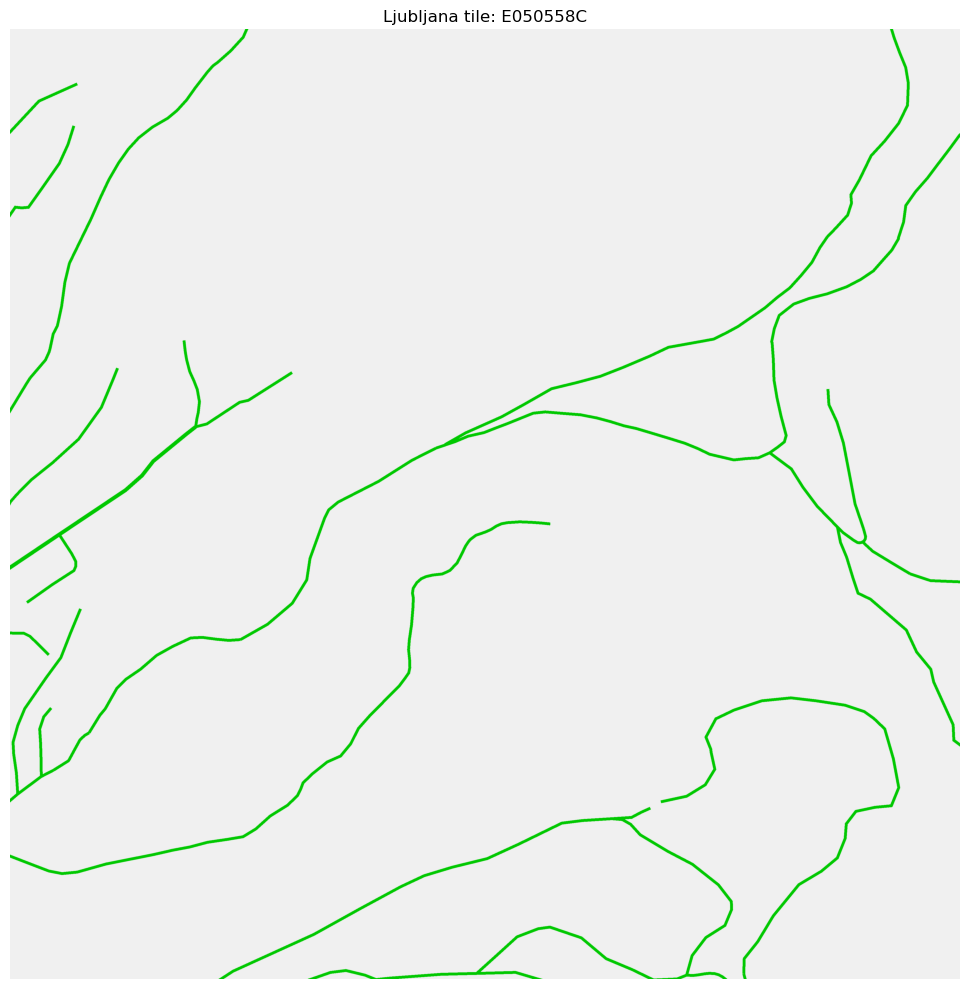

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

tile_name = 'E050558C'
mask_path = MASK_DIR / f"{tile_name}_mask.tif"

with rasterio.open(mask_path) as src:
    mask = src.read(1)

# Convert to RGB
rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
rgb[mask == 0] = [240, 240, 240]  # background - light grey
rgb[mask == 1] = [255, 0,   0]    # major roads - red
rgb[mask == 2] = [0,   0,   255]  # local roads - blue
rgb[mask == 3] = [0,   200, 0]    # minor roads - green

# Show center crop
cx, cy = mask.shape[1]//2, mask.shape[0]//2
crop = rgb[cy-2000:cy+2000, cx-2000:cx+2000]
ax.imshow(crop)

unique, counts = np.unique(mask, return_counts=True)
class_info = {u: c for u, c in zip(unique, counts)}
total_px = mask.size
print("=== Pixel counts ===")
for cls, name in [(0,'background'), (1,'major'), (2,'local'), (3,'minor')]:
    count = class_info.get(cls, 0)
    print(f"Class {cls} ({name}): {count:,} px ({100*count/total_px:.2f}%)")

ax.set_title(f'Ljubljana tile: {tile_name}')
ax.axis('off')
plt.tight_layout()
plt.savefig('ljubljana_mask_check.png', dpi=150)
plt.show()

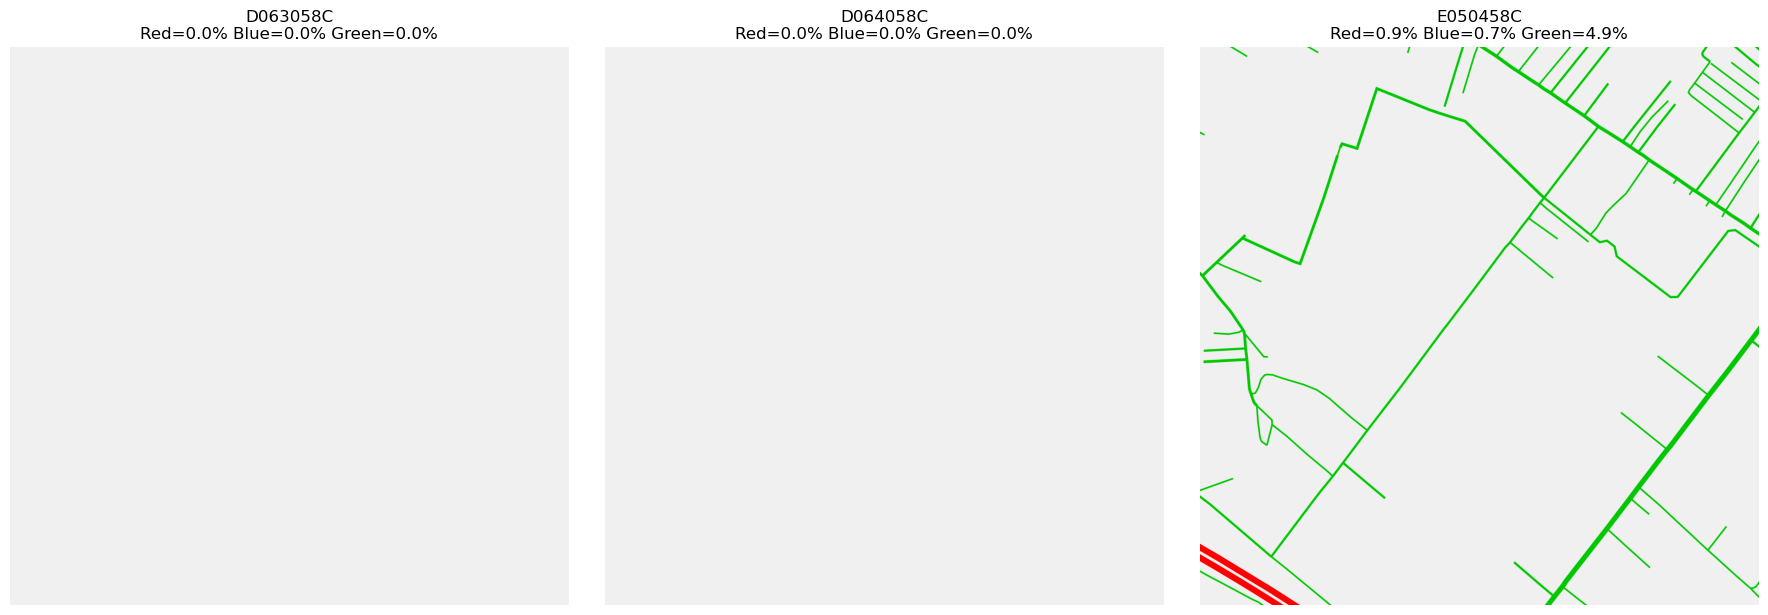

In [16]:
# Use actual Ljubljana tiles we know exist
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Pick 3 from the actual list
tiles_to_check = ['D063058C', 'D064058C', 'E050458C']

for ax, tile_name in zip(axes, tiles_to_check):
    mask_path = MASK_DIR / f"{tile_name}_mask.tif"
    
    if not mask_path.exists():
        ax.set_title(f"{tile_name} NOT FOUND")
        continue
    
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    rgb[mask == 0] = [240, 240, 240]
    rgb[mask == 3] = [0, 200, 0]
    rgb[mask == 2] = [0, 0, 255]
    rgb[mask == 1] = [255, 0, 0]
    
    cx, cy = mask.shape[1]//2, mask.shape[0]//2
    crop = rgb[cy-2000:cy+2000, cx-2000:cx+2000]
    ax.imshow(crop)
    
    unique, counts = np.unique(mask, return_counts=True)
    class_info = {u: c for u, c in zip(unique, counts)}
    total = mask.size
    c1 = 100*class_info.get(1,0)/total
    c2 = 100*class_info.get(2,0)/total
    c3 = 100*class_info.get(3,0)/total
    
    ax.set_title(f'{tile_name}\nRed={c1:.1f}% Blue={c2:.1f}% Green={c3:.1f}%')
    ax.axis('off')

plt.tight_layout()
plt.savefig('ljubljana_actual_check.png', dpi=150)
plt.show()